<a href="https://colab.research.google.com/github/Om4587/Scientific-Analysis/blob/main/Spectral_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

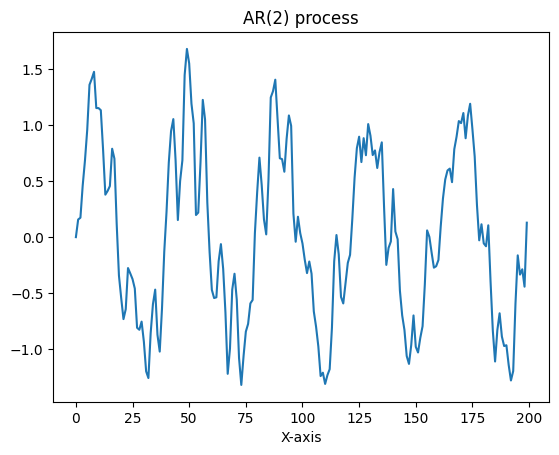

In [37]:
alpha = np.array([-.6,.9])
k = len(alpha)
N = 200
x = np.zeros(N)

for i in range(k,N):
  x[i] = sum(alpha*x[i-k:i]) + np.random.randn()/5

x += np.sin(np.linspace(0,10*np.pi,N))

plt.plot(x)
plt.xlabel('X-axis')
plt.title('AR(%s) process'%k)
plt.show()

In [38]:
# define our time vector
t = np.arange(N)/N

# initialize the fourier coefficients
fc = np.zeros(N,dtype=complex)

# manual fourier transform
for f in range(N):
  # 1) create the complex sine wave
  csw = np.exp(-1j*2*np.pi*f*t)

  # 2) compute the dot product with the signal
  fc[f] = np.dot(csw,x)


# FFT function
fc2 = np.fft.fft(x)

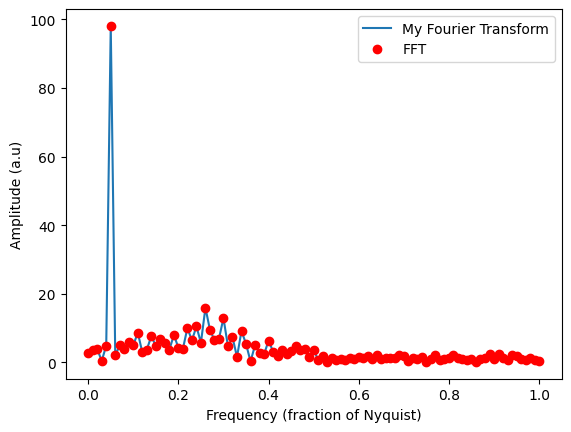

In [40]:
hz = np.linspace(0,1,int(N/2+1))
plt.plot(hz,np.abs(fc[:len(hz)]),label = 'My Fourier Transform')
plt.plot(hz,np.abs(fc2[:len(hz)]),'ro',label = 'FFT')
plt.legend()
plt.xlabel('Frequency (fraction of Nyquist)')
plt.ylabel('Amplitude (a.u)')
plt.show()